# JOBSHEET 2 (Klasifikasi Gambar)

## Praktikum D1 - Memulai Klasifikasi Gambar dengan Dataset Sederhana

try dataset MNIST

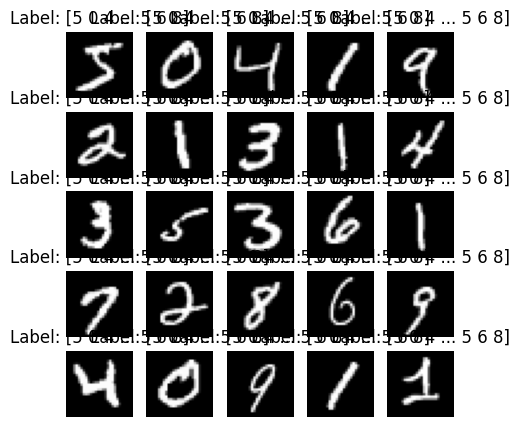

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist

# load data
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# tampilkan contoh
plt.figure(figsize=(5,5))
for i in range(25):
  plt.subplot(5,5,i+1)
  plt.imshow(x_train[i], cmap='gray')
  plt.title(f"Label: {y_train}")
  plt.axis('off')
plt.show()

## Praktikum D2 - Klasifikasi Gambar dengan Model Machine Learning Traditional

using SVM algorithm

In [11]:
from sklearn import svm
from sklearn.metrics import accuracy_score

# flatten
x_train_flat = x_train.reshape(len(x_train), -1) / 255.0
x_test_flat = x_test.reshape(len(x_test), -1) / 255.0

# svm
clf = svm.SVC(kernel='linear', gamma='scale')
clf.fit(x_train_flat[:5000], y_train[:5000]) # gunakan subset karena svm berat
y_pred = clf.predict(x_test_flat)

print("Akurasi", accuracy_score(y_test, y_pred))

Akurasi 0.9101


## Praktikum D3 - Membangung CNN Sederhana

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 33s 19ms/step - accuracy: 0.9415 - loss: 0.1973 - val_accuracy: 0.9778 - val_loss: 0.0819
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 42s 19ms/step - accuracy: 0.9803 - loss: 0.0645 - val_accuracy: 0.9847 - val_loss: 0.0550
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 32s 19ms/step - accuracy: 0.9869 - loss: 0.0425 - val_accuracy: 0.9848 - val_loss: 0.0520
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 31s 19ms/step - accuracy: 0.9899 - loss: 0.0316 - val_accuracy: 0.9847 - val_loss: 0.0592
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 34s 20ms/step - accuracy: 0.9926 - loss: 0.0237 - val_accuracy: 0.9875 - val_loss: 0.0493


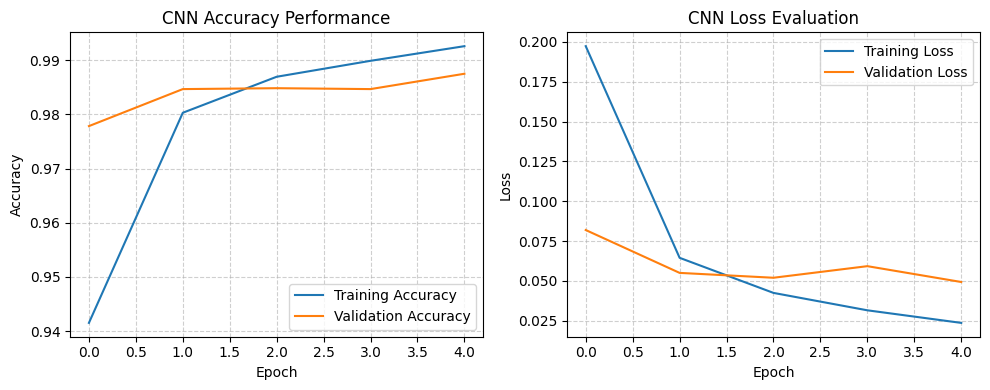

In [13]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# 1. Normalisasi Data (Asumsi x_train, y_train, x_test sudah di-load ke dalam memori)
x_train_cnn = x_train.reshape(-1, 28, 28, 1) / 255.0
x_test_cnn = x_test.reshape(-1, 28, 28, 1) / 255.0

# 2. Arsitektur Model Terstruktur
model = models.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# 3. Kompilasi Model dengan Error Handling yang Tepat
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 4. Eksekusi Pelatihan
history = model.fit(
    x_train_cnn,
    y_train,
    epochs=5,
    validation_split=0.1
)

# 5. Visualisasi Metrik Performa
plt.figure(figsize=(10, 4))

# Plot Akurasi
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('CNN Accuracy Performance')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('CNN Loss Evaluation')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.tight_layout()
plt.show()

Tugas kecil: Tambahkan satu lapisan Conv2D lagi sebelum Flatten. Apakah akurasinya meningkat?

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 53s 31ms/step - accuracy: 0.9549 - loss: 0.1475 - val_accuracy: 0.9852 - val_loss: 0.0522
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 53s 31ms/step - accuracy: 0.9853 - loss: 0.0470 - val_accuracy: 0.9900 - val_loss: 0.0417
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 82s 31ms/step - accuracy: 0.9900 - loss: 0.0321 - val_accuracy: 0.9910 - val_loss: 0.0365
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 52s 31ms/step - accuracy: 0.9928 - loss: 0.0231 - val_accuracy: 0.9893 - val_loss: 0.0390
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 52s 31ms/step - accuracy: 0.9939 - loss: 0.0181 - val_accuracy: 0.9888 - val_loss: 0.0474


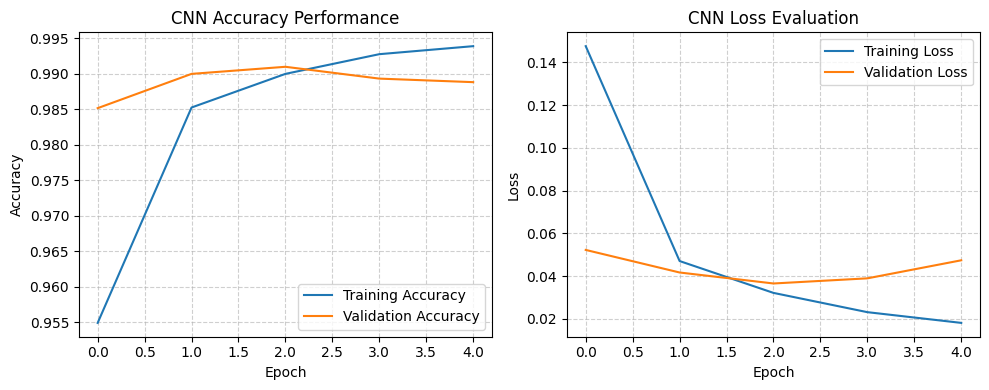

In [14]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# 1. Normalisasi Data (Asumsi x_train, y_train, x_test sudah di-load ke dalam memori)
x_train_cnn = x_train.reshape(-1, 28, 28, 1) / 255.0
x_test_cnn = x_test.reshape(-1, 28, 28, 1) / 255.0

# 2. Arsitektur Model Terstruktur
model = models.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # add conv2d
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# 3. Kompilasi Model dengan Error Handling yang Tepat
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 4. Eksekusi Pelatihan
history = model.fit(
    x_train_cnn,
    y_train,
    epochs=5,
    validation_split=0.1
)

# 5. Visualisasi Metrik Performa
plt.figure(figsize=(10, 4))

# Plot Akurasi
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('CNN Accuracy Performance')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('CNN Loss Evaluation')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.tight_layout()
plt.show()

Ya, penambahan lapisan Conv2D terbukti meningkatkan akurasi validasi (dari stagnasi ~0.988 menjadi ~0.991) karena arsitektur jaringan yang lebih dalam memungkinkan ekstraksi pola fitur visual yang lebih kompleks. Meskipun demikian, penambahan kompleksitas ini memicu indikasi awal *overfitting*, yang dibuktikan oleh tren kenaikan *validation loss* setelah epoch kedua sementara *training loss* terus mengalami penurunan.

## Praktikum D4 - Eksperimen dengan Dataset Lebih Kompleks (CIFAR-10)

Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 58s 41ms/step - accuracy: 0.3322 - loss: 2.2336 - val_accuracy: 0.4440 - val_loss: 1.5253
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 57s 41ms/step - accuracy: 0.4798 - loss: 1.4574 - val_accuracy: 0.5192 - val_loss: 1.3628
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 56s 40ms/step - accuracy: 0.5552 - loss: 1.2642 - val_accuracy: 0.5608 - val_loss: 1.2451
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 56s 40ms/step - accuracy: 0.6073 - loss: 1.1227 - val_accuracy: 0.6148 - val_loss: 1.1234
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 82s 40ms/step - accuracy: 0.6421 - loss: 1.0257 - val_accuracy: 0.6020 - val_loss: 1.1472
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 82s 40ms/step - accuracy: 0.6710 - loss: 0.9445 - val_accuracy: 0.6430 - val_loss: 1.0720
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 81s 39ms/step - accuracy: 0.6933 - loss: 0.8731 - val_accuracy: 0.6362 - val_loss: 1.1278
Epoch 8/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 55s 39ms/step - accuracy: 0.7171 -

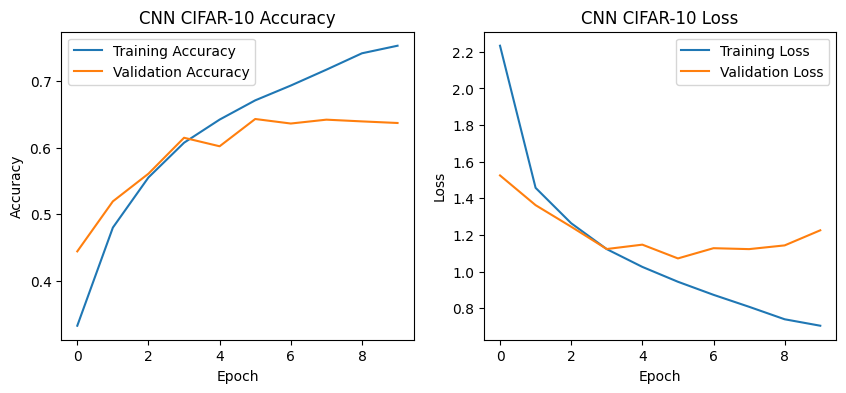

In [17]:
from tensorflow.keras.datasets import cifar10

(x_train, y_train), (x_test, y_test) = cifar10.load_data()

model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    x_train,
    y_train,
    epochs=10,
    validation_split=0.1
)

# plothistory
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('CNN CIFAR-10 Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('CNN CIFAR-10 Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()